<a href="https://colab.research.google.com/github/amnananaa/ml-lab-open-ended/blob/main/24F_BSAI_126_ML_Lab_Open_Ended.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008  

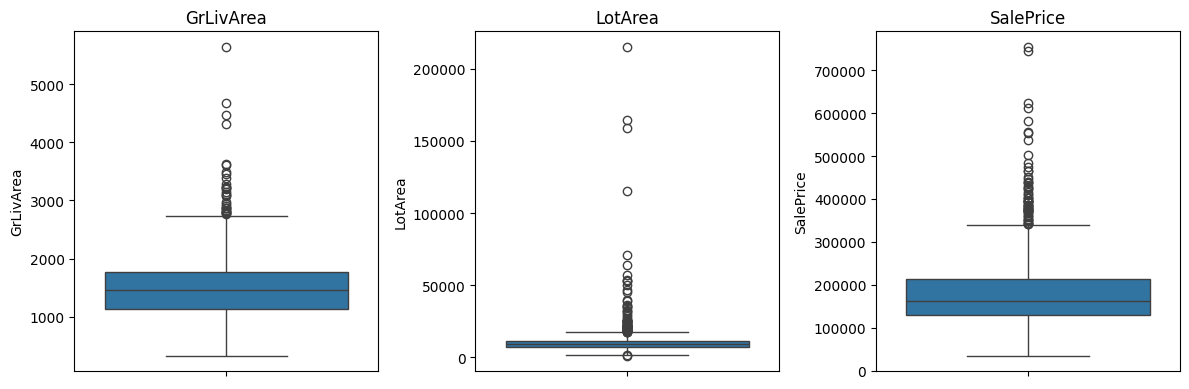

Rows before: 1460
Rows after: 1301


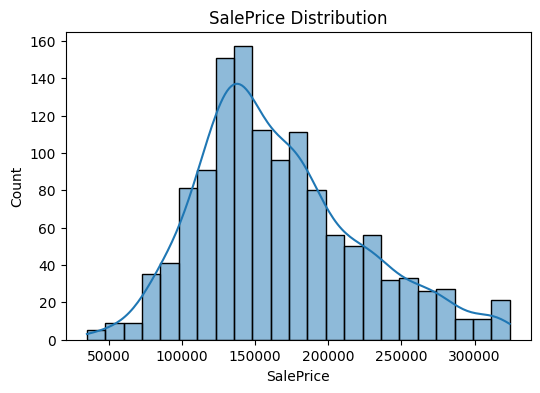

Category
Low       435
Medium    433
High      433
Name: count, dtype: int64
R2 Score: 0.8768263355454559
MAE: 14722.366830424497
RMSE: 19835.305643172844


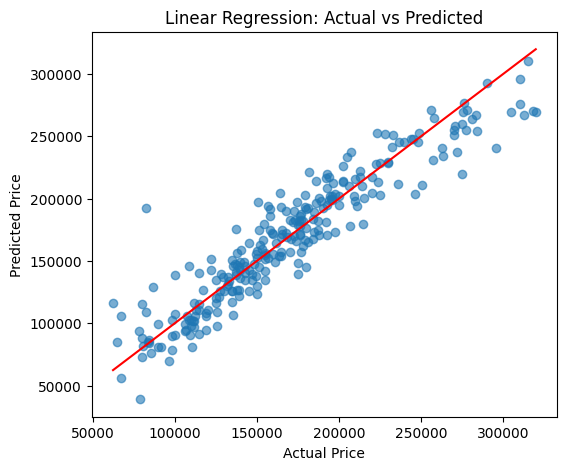

Accuracy: 0.8084291187739464
              precision    recall  f1-score   support

        High       0.86      0.86      0.86        96
         Low       0.82      0.88      0.85        75
      Medium       0.74      0.69      0.71        90

    accuracy                           0.81       261
   macro avg       0.81      0.81      0.81       261
weighted avg       0.81      0.81      0.81       261



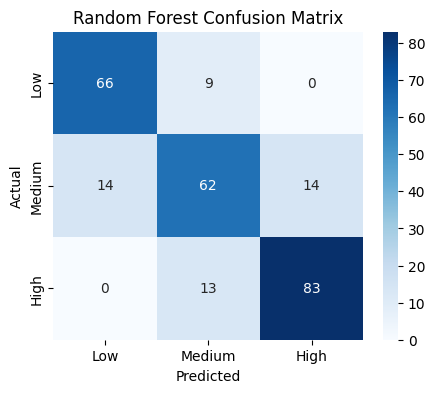

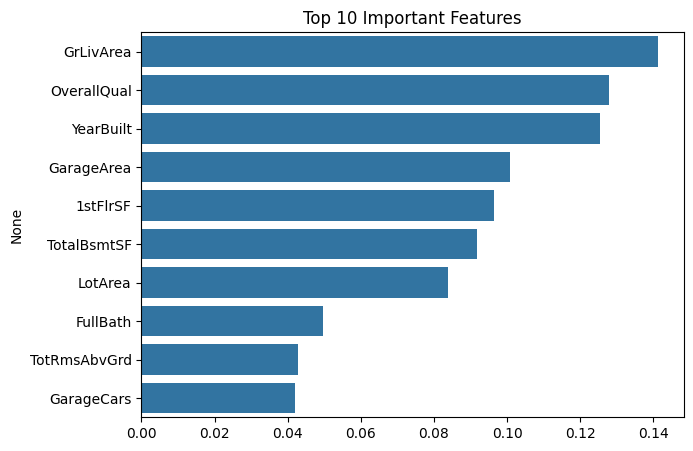

Linear Regression R2 Score: 0.8768
Random Forest Accuracy: 0.8084


In [1]:
# Project: House Price & Category Prediction
# Roll No: 24F-BSAI-126

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

url = "https://raw.githubusercontent.com/amnananaa/ml-lab-open-ended/main/house-prices/train.csv"
df = pd.read_csv(url)

# Dataset Description
print(df.shape)
print(df.head())
df.info()
print(df['SalePrice'].describe())

# Selecting Features
cols = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'GarageArea',
        '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'LotArea',
        'Neighborhood', 'SalePrice']
data = df[cols].copy()

# Handling Missing Values
print(data.isnull().sum())
for c in data.select_dtypes(include='number').columns:
    data[c] = data[c].fillna(data[c].median())
data['Neighborhood'] = data['Neighborhood'].fillna(data['Neighborhood'].mode()[0])

# Outlier Detection
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.boxplot(y=data['GrLivArea'])
plt.title('GrLivArea')
plt.subplot(1, 3, 2)
sns.boxplot(y=data['LotArea'])
plt.title('LotArea')
plt.subplot(1, 3, 3)
sns.boxplot(y=data['SalePrice'])
plt.title('SalePrice')
plt.tight_layout()
plt.show()

# Outlier Removal
print("Rows before:", data.shape[0])
for c in ['GrLivArea', 'LotArea', 'SalePrice']:
    q1 = data[c].quantile(0.25)
    q3 = data[c].quantile(0.75)
    iqr = q3 - q1
    data = data[(data[c] >= q1 - 1.5 * iqr) & (data[c] <= q3 + 1.5 * iqr)]
print("Rows after:", data.shape[0])

# Price Distribution
plt.figure(figsize=(6, 4))
sns.histplot(data['SalePrice'], kde=True)
plt.title('SalePrice Distribution')
plt.show()

# Creating Price Category (Low, Medium, High)
data['Category'] = pd.qcut(data['SalePrice'], 3, labels=['Low', 'Medium', 'High'])
print(data['Category'].value_counts())

# Encoding Location
data = pd.get_dummies(data, columns=['Neighborhood'], drop_first=True)

# Train Test Split
X = data.drop(['SalePrice', 'Category'], axis=1)
y_price = data['SalePrice']
y_cat = data['Category']

X_train, X_test, y_train, y_test, yc_train, yc_test = train_test_split(
    X, y_price, y_cat, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Linear Regression (Price Prediction)
lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred = lr.predict(X_test_s)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

# Actual vs Predicted Price
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Linear Regression: Actual vs Predicted')
plt.show()

# Random Forest (Category Classification)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_s, yc_train)
yc_pred = rf.predict(X_test_s)

acc = accuracy_score(yc_test, yc_pred)
print("Accuracy:", acc)
print(classification_report(yc_test, yc_pred))

# Confusion Matrix
cm = confusion_matrix(yc_test, yc_pred, labels=['Low', 'Medium', 'High'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

# Feature Importance
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(7, 5))
sns.barplot(x=imp.values, y=imp.index)
plt.title('Top 10 Important Features')
plt.show()

# Performance Comparison
print("Linear Regression R2 Score:", round(r2, 4))
print("Random Forest Accuracy:", round(acc, 4))